# 💳 Credit Risk Prediction

This project focuses on predicting whether a loan applicant is likely to default on a loan using machine learning techniques.

## Introduction

Financial institutions need to evaluate whether a loan applicant is likely to repay a loan or default. Data analysis and machine learning can help identify patterns in applicant information such as income, loan amount, education, and credit history.

## Problem Statement

The goal of this project is to build a machine learning model that predicts whether a loan applicant will default on a loan. The dataset will be explored, cleaned, and analyzed, and a classification model will be trained to make predictions.

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression   
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


In [3]:
# laod the dataset
df = pd.read_csv("Loan_prediction_dataset.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Understanding

In this step we explore the dataset structure to understand the number of rows, columns, and the types of features available.

In [4]:
print("The shape of the dataset is:", df.shape)


The shape of the dataset is: (614, 13)


In [5]:
print("The columns in the dataset are:", df.columns)

The columns in the dataset are: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
# check for missing values 
print("Missing values in the dataset:\n", df.isnull().sum())

Missing values in the dataset:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [12]:
# missing values in in sorted order
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Credit_History       50
Self_Employed        32
LoanAmount           22
Dependents           15
Loan_Amount_Term     14
Gender               13
Married               3
Education             0
Loan_ID               0
CoapplicantIncome     0
ApplicantIncome       0
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
# missing value percentage
missing_percentage = df.isnull().sum() / len(df) * 100
print("Missing value percentage in the dataset:\n", missing_percentage)

Missing value percentage in the dataset:
 Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64


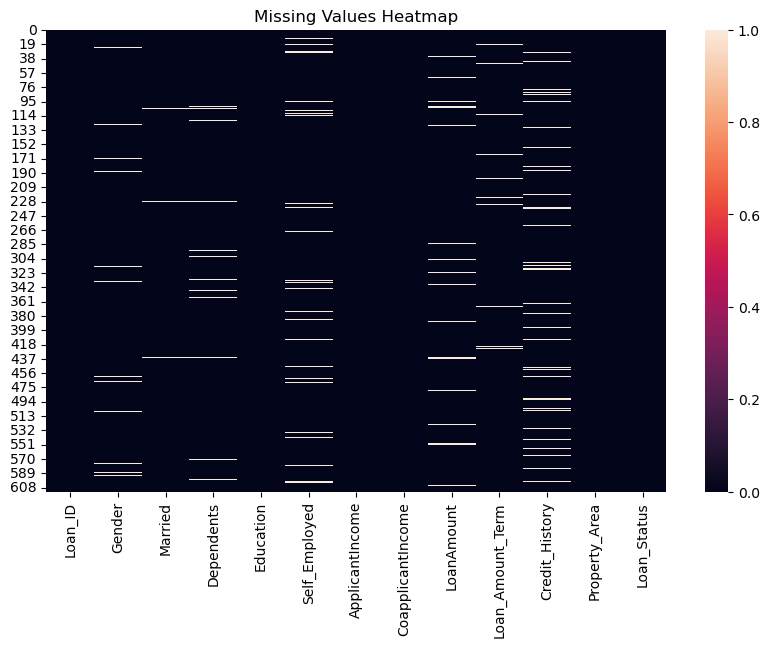

In [14]:
# visualize the missing values using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull())
plt.title("Missing Values Heatmap")
plt.show()



In [29]:
# filling the missing values with mode for categorical columns 

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# filling the missing values with median for numerical columns
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())  
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# Credit history is important for prediction
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])



In [30]:
#verify that there are no missing values left
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [32]:
# drop the Loan_ID column as it is not useful for prediction
df.drop('Loan_ID', axis=1, inplace=True)

In [35]:
df.dtypes

Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [36]:
# Dependent column is object type, and the values in the column are numeric so will look at the column  and adjust it.
df['Dependents'].head(10)

0     0
1     1
2     0
3     0
4     0
5     2
6     0
7    3+
8     2
9     1
Name: Dependents, dtype: str

In [37]:
df['Dependents'].value_counts()

Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

In [38]:
# the problem is 3+ , so we will replace 4

df['Dependents'] = df['Dependents'].replace('3+', '4')

In [39]:
# now check the value counts again
df['Dependents'].value_counts()

Dependents
0    360
1    102
2    101
4     51
Name: count, dtype: int64

In [42]:
# convert the column to numeric
df['Dependents'] = df['Dependents'].astype(int)

## **Visualization**

<Axes: xlabel='Gender', ylabel='count'>

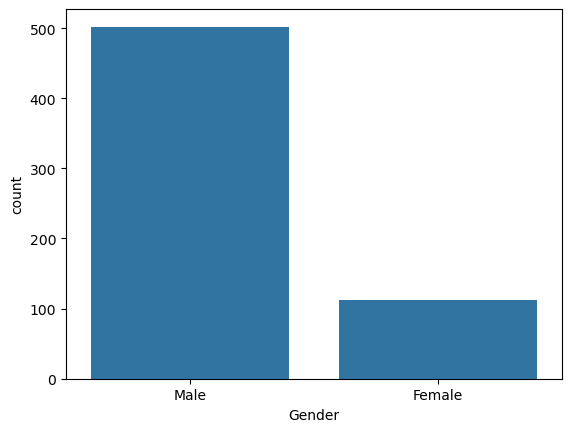

In [47]:
# #Visalization to count column Gender
sns.countplot(data=df , x='Gender')

<Axes: xlabel='Education', ylabel='count'>

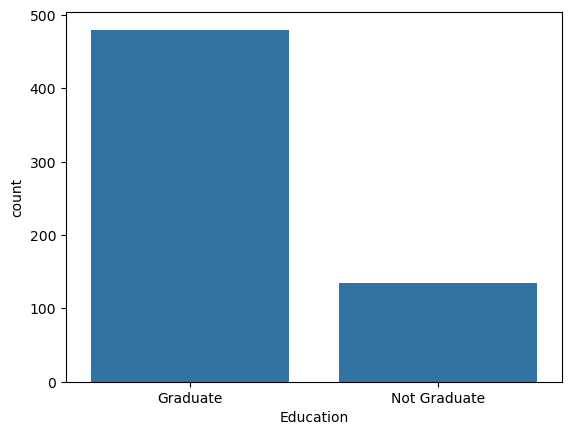

In [46]:
#Visalization to count column Education
sns.countplot(data=df , x='Education')

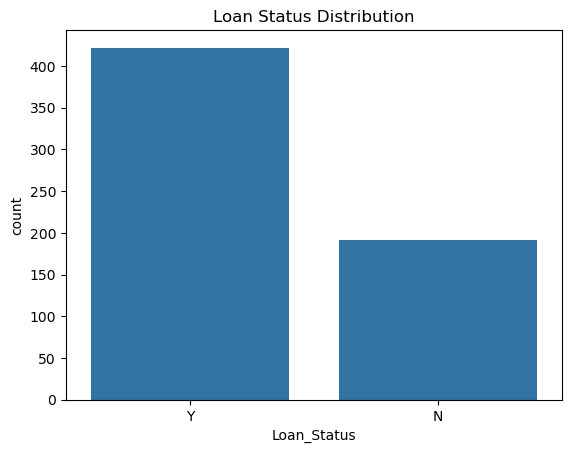

In [51]:
# Visualization of Loan Status distribution
sns.countplot(data=df, x='Loan_Status')
plt.title('Loan Status Distribution')
plt.show()

Text(0.5, 1.0, 'Loan Status by Education Level')

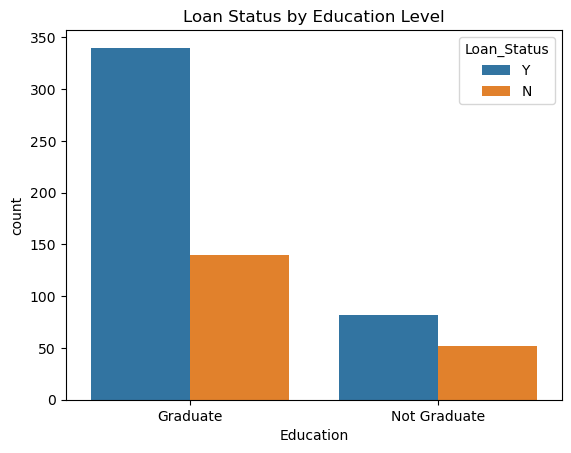

In [49]:
# distribution of Loan_Status based on the Education level 
sns.countplot(data=df, x='Education', hue='Loan_Status')
plt.title('Loan Status by Education Level')

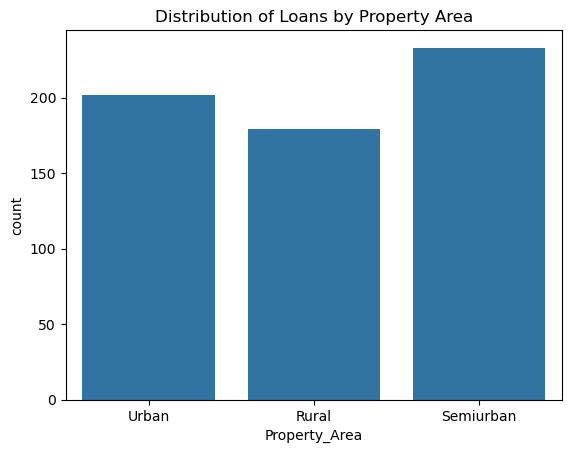

In [52]:
# Countplot for Property_Area distribution
sns.countplot(data=df, x='Property_Area')
plt.title('Distribution of Loans by Property Area')
plt.show()

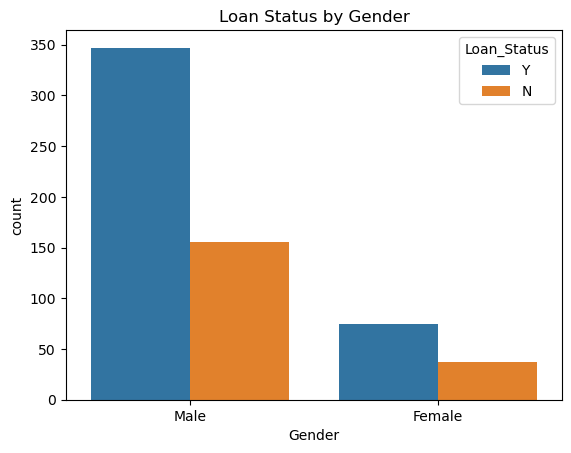

In [53]:
# Countplot for Loan Status by Gender
sns.countplot(data=df, x='Gender', hue='Loan_Status')
plt.title('Loan Status by Gender')
plt.show()

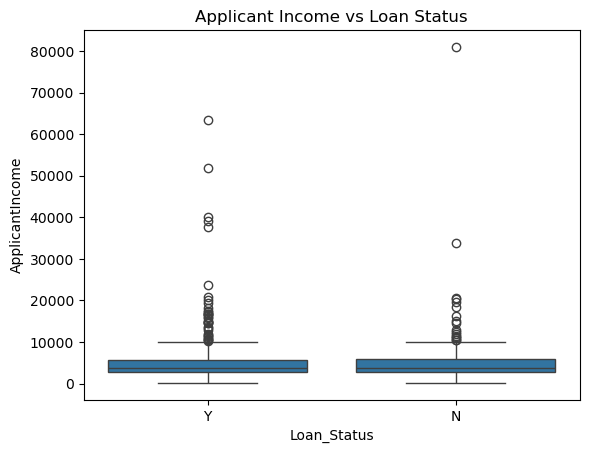

In [55]:
# Boxplot of ApplicantIncome by Loan Status
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome')
plt.title('Applicant Income vs Loan Status')
plt.show()

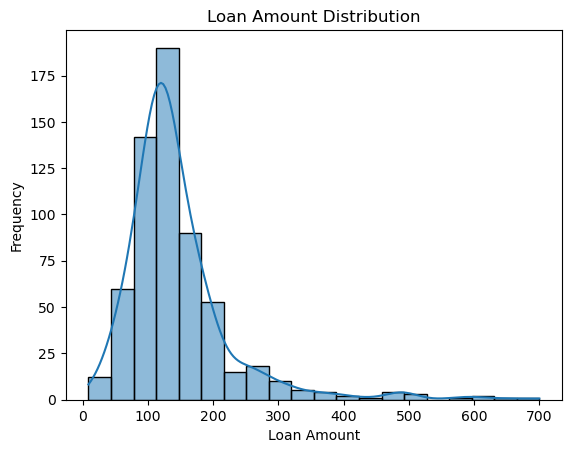

In [ ]:
#histogram of LoanAmount with KDE

sns.histplot(df['LoanAmount'], kde=True, bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

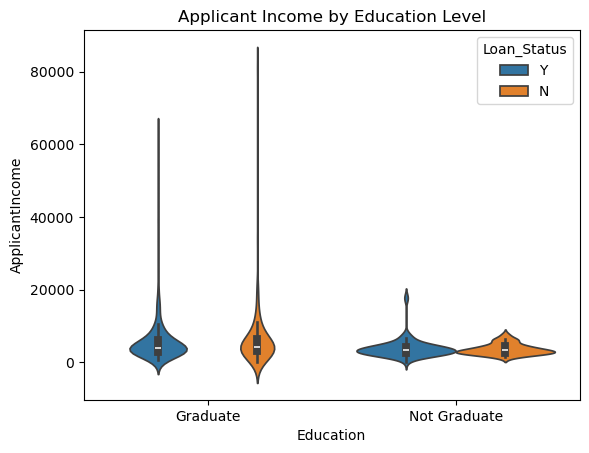

In [66]:
#. Violin plot of ApplicantIncome vs Education
sns.violinplot(data=df, x='Education', y='ApplicantIncome', hue='Loan_Status')
plt.title('Applicant Income by Education Level')
plt.show()

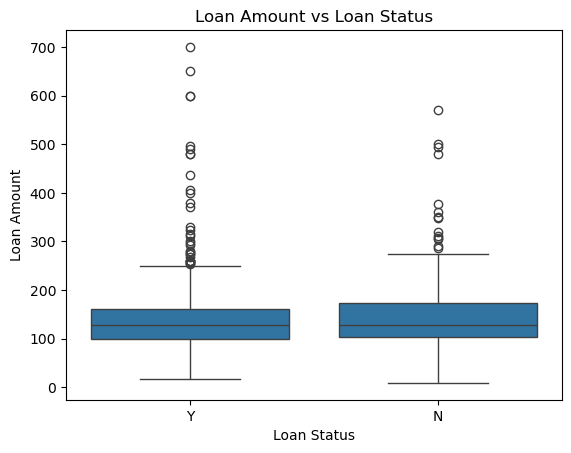

In [67]:
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.show()

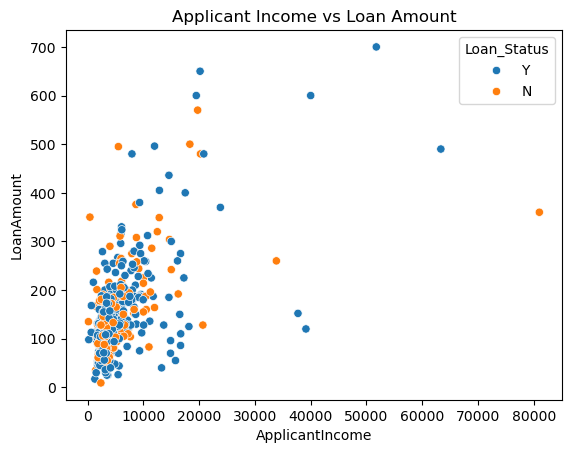

In [68]:
# Scatter plot of ApplicantIncome vs LoanAmount
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status')
plt.title('Applicant Income vs Loan Amount')
plt.show()

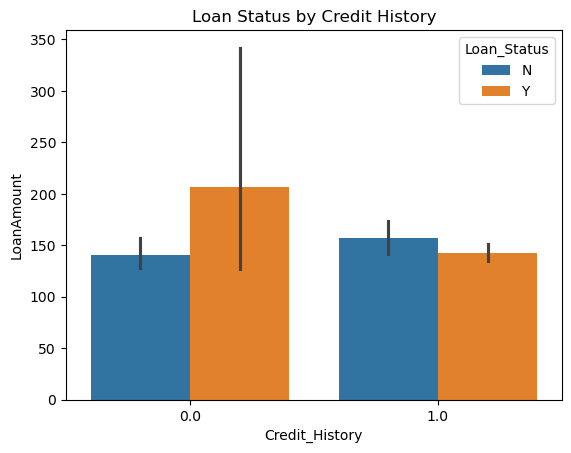

In [69]:
# Barplot for Credit History and Loan Status
sns.barplot(data=df, x='Credit_History', y='LoanAmount', hue='Loan_Status')
plt.title('Loan Status by Credit History')
plt.show()


## **Data Preprocessing**

In [70]:
# Replace 'Loan_Status' values: 'Y' with 1 and 'N' with 0 for binary encoding
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

In [71]:
# Convert all categorical 'object' type columns to dummy/one-hot encoding
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5224\1839167098.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,True
1,1,4583,1508.0,128.0,360.0,1.0,0,True,True,False,False,False,False
2,0,3000,0.0,66.0,360.0,1.0,1,True,True,False,True,False,True
3,0,2583,2358.0,120.0,360.0,1.0,1,True,True,True,False,False,True
4,0,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,True


In [72]:
# Now separate features and target variable
X = df.drop('Loan_Status', axis=1)  # Features
y = df['Loan_Status']  # Target variable


In [80]:
# splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=40)

In [81]:
# train the model
model = LogisticRegression()
model.fit(X_train, y_train)

c:\Users\Administrator\miniconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [82]:
# predict the model
y_pred = model.predict(X_test)

In [83]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy of the model:", accuracy)
print("Confusion Matrix:\n", cm)


Accuracy of the model: 0.8709677419354839
Confusion Matrix:
 [[ 7  7]
 [ 1 47]]


In [86]:
# comparison of predicted values vs actual values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head(10))

     Actual  Predicted
439       1          1
348       1          1
459       0          1
71        1          1
51        1          1
12        1          1
243       1          1
310       1          1
222       1          1
373       0          0


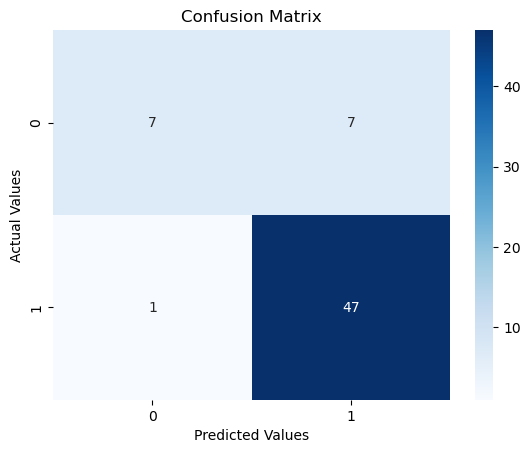

In [89]:
# visualize the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

## 📊 Conclusion

This task explored the **Loan Prediction dataset** to understand the factors that influence loan approval.

First, the dataset was cleaned by handling missing values and converting categorical columns into numeric format. Then several visualizations were created to understand patterns in income, education, and loan amounts. After the analysis, a **Logistic Regression model** was trained to predict whether a loan will be approved.

### 📈 Model Performance

**Model Accuracy:** `0.87` (87%)

**Confusion Matrix**

| Actual \ Predicted | Rejected | Approved |
|---|---|---|
| Rejected | 7 | 7 |
| Approved | 1 | 47 |

### 🔎 Key Takeaway

The model correctly predicted most loan approvals and rejections, achieving strong overall performance.  
This task demonstrates how **data cleaning, visualization, and machine learning** can be combined to build a simple and effective loan approval prediction system.